In [5]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pandas.core import groupby

In [30]:
df = pd.read_excel('US Superstore data.xls')
df.head(20)
df.columns
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

In [16]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


Which state have the most sales?

In [25]:
most_sale = df.groupby('State')['Sales'].sum()
#top_city = most_sales_city.nlargest(1)
most_sale = most_sale.head(1)
print('State with the Most Sales:')
print(most_sale)



State with the Most Sales:
State
Alabama    19510.64
Name: Sales, dtype: float64


Which states have the most sales?

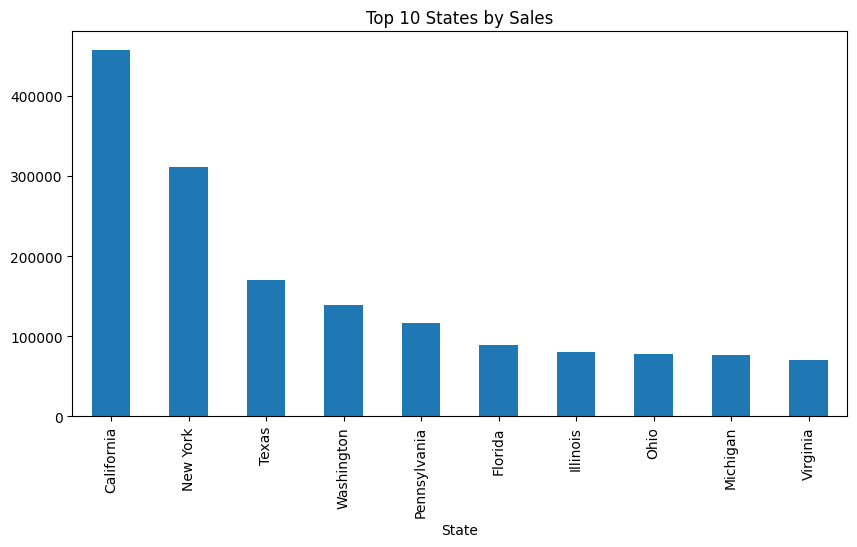

In [31]:
state_sales = df.groupby("State")["Sales"].sum().sort_values(ascending=False)
state_sales.head(10).plot(kind="bar", figsize=(10,5))
plt.title("Top 10 States by Sales")
plt.show()


What is the difference between New York and California in terms of sales and profit? (Compare the total sales and profit between New York and California.)

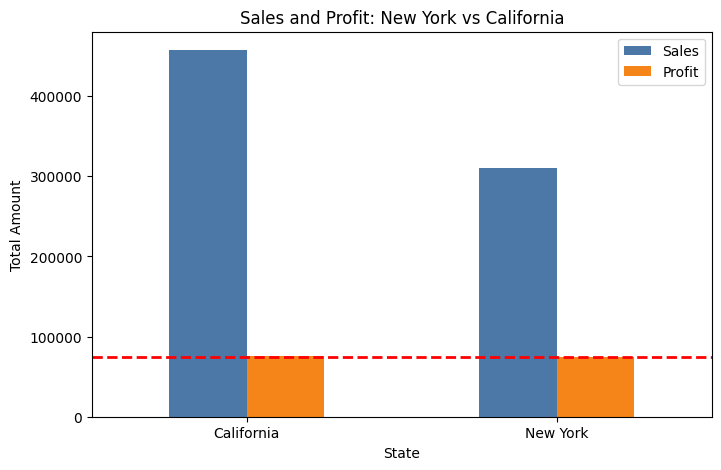

In [34]:
ny_ca = df[df["State"].isin(["New York", "California"])] \
          .groupby("State")[["Sales","Profit"]].sum()

# Plot bars
ax = ny_ca.plot(kind="bar", figsize=(8,5), color=["#4C78A8","#F58518"])
plt.title("Sales and Profit: New York vs California")
plt.ylabel("Total Amount")
plt.xticks(rotation=0)

# Add a horizontal line at the smaller profit value
min_profit = ny_ca["Profit"].min()
plt.axhline(y=min_profit, color="red", linestyle="--", linewidth=2)

plt.legend()
plt.show()


Who is an outstanding customer in New York?

In [35]:
ny_customers = df[df["State"]=="New York"]
ny_summary = ny_customers.groupby(["Customer ID","Customer Name"])[["Sales","Profit"]].sum().reset_index()
ny_summary = ny_summary.sort_values("Profit", ascending=False)
print(ny_summary.head())

    Customer ID     Customer Name      Sales     Profit
380    TA-21385      Tom Ashbrook  13723.498  4599.2073
230    KD-16495     Keith Dawkins   5854.194  2510.8903
228    KD-16270     Karen Daniels   6241.282  2283.0463
300    NM-18445      Nathan Mautz   4821.292  2247.1904
387    TB-21400  Tom Boeckenhauer   6999.960  2239.9872


Are there any differences among states in profitability?

                            Sales      Profit  Profit Margin %
State                                                         
Alabama                19510.6400   5786.8253        29.659844
Arizona                35282.0010  -3427.9246        -9.715789
Arkansas               11678.1300   4008.6871        34.326447
California            457687.6315  76381.3871        16.688541
Colorado               32108.1180  -6527.8579       -20.330864
Connecticut            13384.3570   3511.4918        26.235790
Delaware               27451.0690   9977.3748        36.346034
District of Columbia    2865.0200   1059.5893        36.983662
Florida                89473.7080  -3399.3017        -3.799219
Georgia                49095.8400  16250.0433        33.098615
Idaho                   4382.4860    826.7231        18.864250
Illinois               80166.1010 -12607.8870       -15.727205
Indiana                53555.3600  18382.9363        34.325110
Iowa                    4579.7600   1183.8119        25

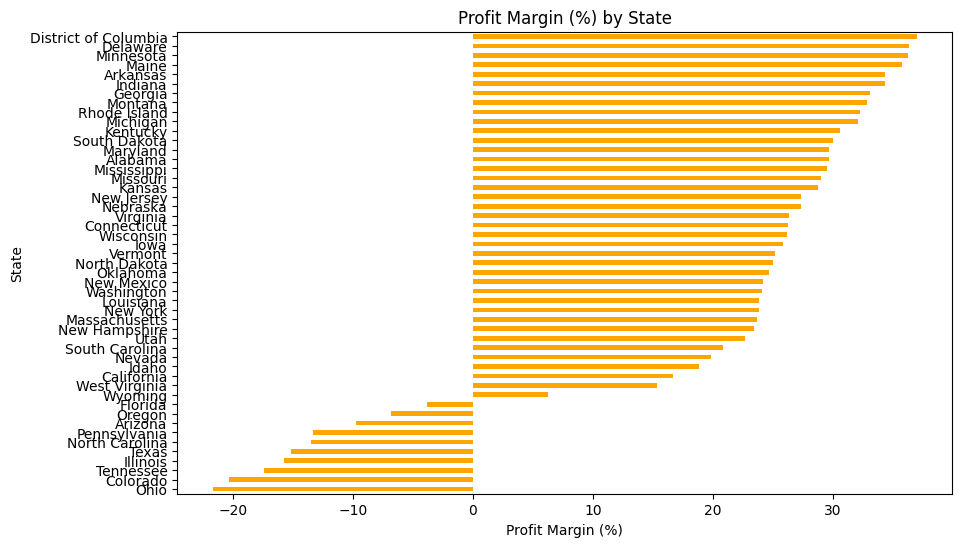

In [36]:
state_summary = df.groupby("State")[["Sales","Profit"]].sum()

# Add Profit Margin
state_summary["Profit Margin %"] = 100 * state_summary["Profit"] / state_summary["Sales"]

print(state_summary)

# Quick bar chart of Profit Margin
state_summary["Profit Margin %"].sort_values().plot(kind="barh", figsize=(10,6), color="orange")
plt.title("Profit Margin (%) by State")
plt.xlabel("Profit Margin (%)")
plt.show()


The Pareto Principle, also known as the 80/20 rule, is a concept derived from the work of Italian economist Vilfredo Pareto. It states that roughly 80% of the effects come from 20% of the causes. For instance, identifying the top 20% of products that generate 80% of sales or the top 20% of customers that contribute to 80% of profit can help in prioritizing efforts and resources. This focus can lead to improved efficiency and effectiveness in business strategies. Can we apply Pareto principle to customers and Profit ? (Determine if 20% of the customers contribute to 80% of the profit.)

Total customers: 793
Customers needed for 80% profit: 152
That’s about 19.17% of customers


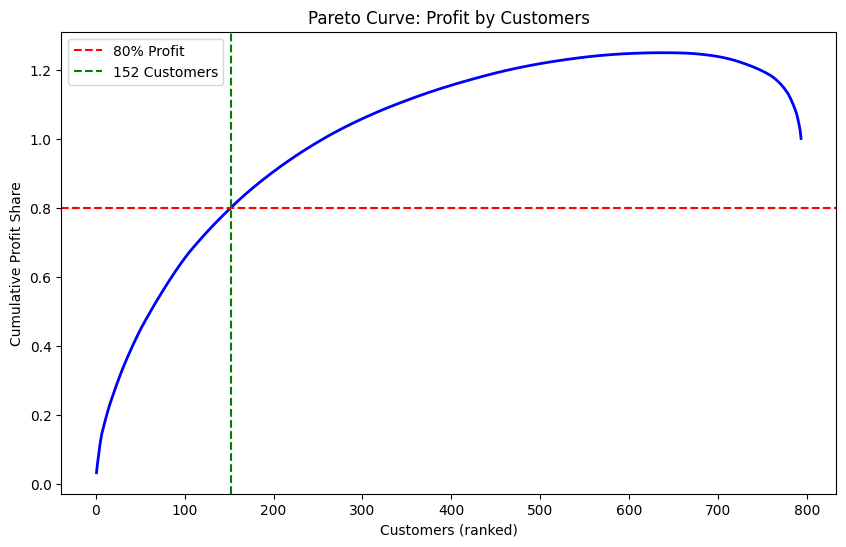

In [37]:
# Aggregate profit by customer
cust_profit = df.groupby("Customer Name")["Profit"].sum().sort_values(ascending=False)

# Calculate cumulative share of profit
cum_profit = cust_profit.cumsum() / cust_profit.sum()

# Find cutoff: number of customers needed to reach 80% of profit
total_customers = len(cust_profit)
top_customers = (cum_profit <= 0.80).sum()
top_percent = 100 * top_customers / total_customers

print(f"Total customers: {total_customers}")
print(f"Customers needed for 80% profit: {top_customers}")
print(f"That’s about {top_percent:.2f}% of customers")

# Plot cumulative curve
plt.figure(figsize=(10,6))
plt.plot(range(1, total_customers+1), cum_profit.values, color="blue", lw=2)
plt.axhline(0.80, color="red", linestyle="--", label="80% Profit")
plt.axvline(top_customers, color="green", linestyle="--", label=f"{top_customers} Customers")
plt.title("Pareto Curve: Profit by Customers")
plt.xlabel("Customers (ranked)")
plt.ylabel("Cumulative Profit Share")
plt.legend()
plt.show()

What are the Top 20 cities by Sales ? What about the Top 20 cities by Profit ? Are there any difference among cities in profitability ? (Identify the top 20 cities based on total sales and total profit and analyze differences in profitability among these cities.)


Top 20 Cities by Profit:
City
New York City    62036.9837
Los Angeles      30440.7579
Seattle          29156.0967
San Francisco    17507.3854
Detroit          13181.7908
Lafayette        10018.3876
Jackson           7581.6828
Atlanta           6993.6629
Minneapolis       6824.5846
San Diego         6377.1960
Springfield       6200.6974
Columbus          5897.1013
Newark            5793.7588
Columbia          5606.1167
Richmond          5567.2486
Providence        5505.6569
Henderson         4911.8609
Arlington         4169.6969
Lakewood          3234.0278
Milwaukee         2793.0851
Name: Profit, dtype: float64


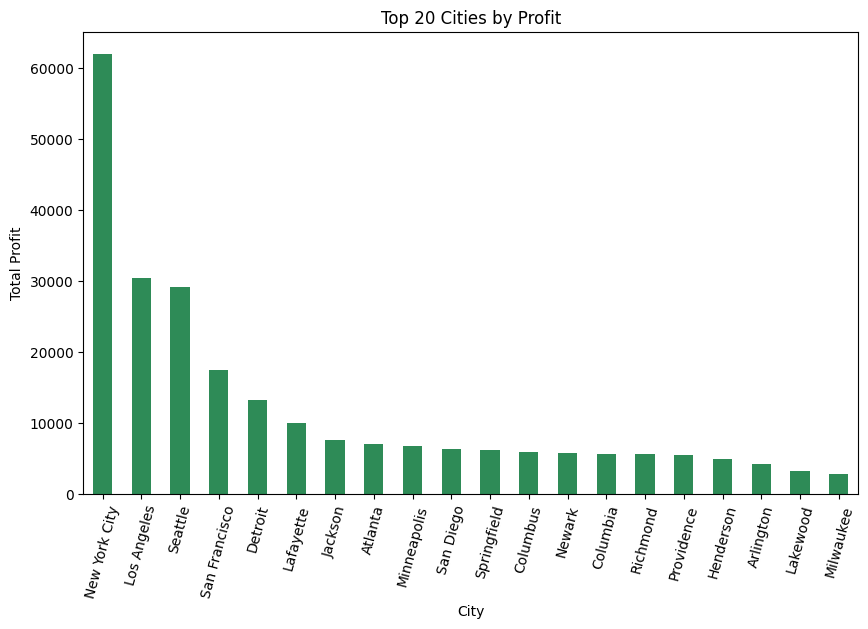

In [40]:
# --- Top 20 cities by Profit ---
top_profit = df.groupby("City")["Profit"].sum().sort_values(ascending=False).head(20)
print("\nTop 20 Cities by Profit:")
print(top_profit)

plt.figure(figsize=(10,6))
top_profit.plot(kind="bar", color="seagreen")
plt.title("Top 20 Cities by Profit")
plt.ylabel("Total Profit")
plt.xticks(rotation=75)
plt.show()

Top 20 Cities by Sales:
City
New York City    256368.1610
Los Angeles      175851.3410
Seattle          119540.7420
San Francisco    112669.0920
Philadelphia     109077.0130
Houston           64504.7604
Chicago           48539.5410
San Diego         47521.0290
Jacksonville      44713.1830
Springfield       43054.3420
Detroit           42446.9440
Columbus          38706.2430
Newark            28576.1190
Columbia          25283.3240
Lafayette         25036.2000
Jackson           24963.8580
San Antonio       21843.5280
Burlington        21668.0820
Arlington         20214.5320
Dallas            20131.9322
Name: Sales, dtype: float64


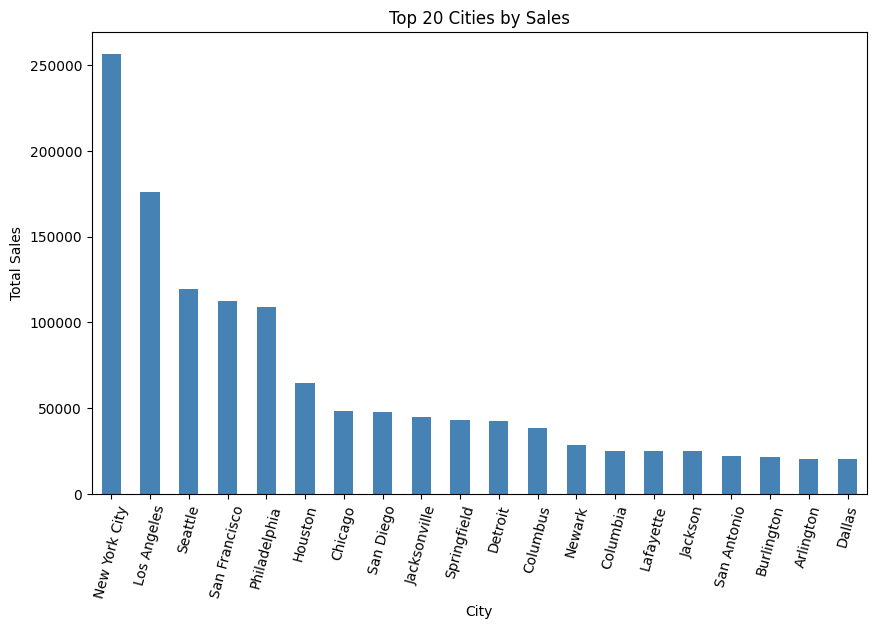

In [41]:
# --- Top 20 cities by Sales ---
top_sales = df.groupby("City")["Sales"].sum().sort_values(ascending=False).head(20)
print("Top 20 Cities by Sales:")
print(top_sales)

plt.figure(figsize=(10,6))
top_sales.plot(kind="bar", color="steelblue")
plt.title("Top 20 Cities by Sales")
plt.ylabel("Total Sales")
plt.xticks(rotation=75)
plt.show()



Profitability among Top Cities:
                     Sales      Profit  Profit Margin %
City                                                   
Atlanta         17197.8400   6993.6629        40.665938
Minneapolis     16870.5400   6824.5846        40.452674
Lafayette       25036.2000  10018.3876        40.015608
Providence      15980.6500   5505.6569        34.452021
Detroit         42446.9440  13181.7908        31.054746
Richmond        18137.9300   5567.2486        30.693958
Jackson         24963.8580   7581.6828        30.370637
Henderson       17549.0680   4911.8609        27.989298
Milwaukee       11410.2200   2793.0851        24.478801
Seattle        119540.7420  29156.0967        24.390092
New York City  256368.1610  62036.9837        24.198396
Columbia        25283.3240   5606.1167        22.173179
Arlington       20214.5320   4169.6969        20.627225
Newark          28576.1190   5793.7588        20.274827
Lakewood        18192.0470   3234.0278        17.777152
Los Angeles    

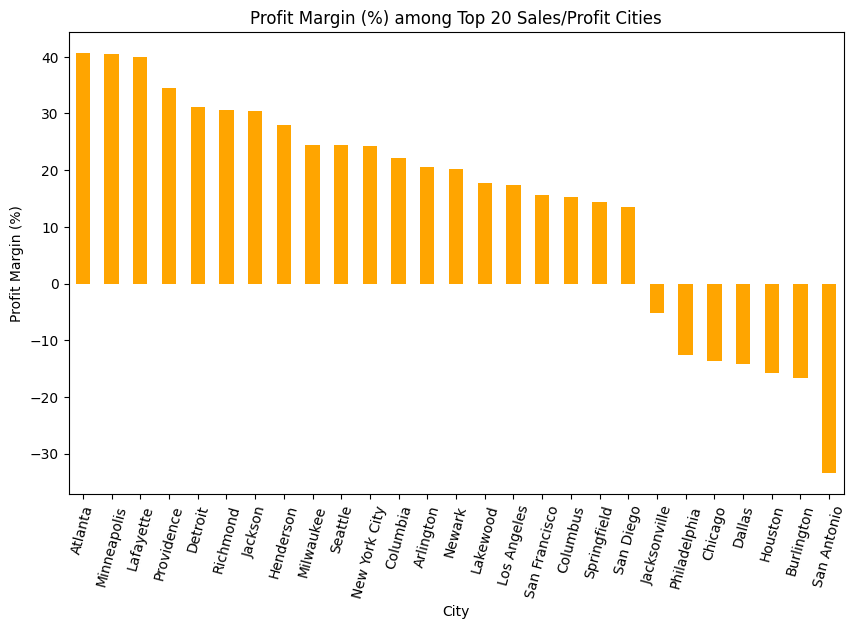

In [42]:

# --- Profitability comparison (Profit Margin %) ---
city_summary = df.groupby("City")[["Sales","Profit"]].sum()
city_summary["Profit Margin %"] = 100 * city_summary["Profit"] / city_summary["Sales"]

# Focus only on cities that appear in top 20 sales or profit
selected_cities = list(set(top_sales.index) | set(top_profit.index)) # Convert the set to a list here
city_compare = city_summary.loc[selected_cities].sort_values("Profit Margin %", ascending=False)

print("\nProfitability among Top Cities:")
print(city_compare)

plt.figure(figsize=(10,6))
city_compare["Profit Margin %"].plot(kind="bar", color="orange")
plt.title("Profit Margin (%) among Top 20 Sales/Profit Cities")
plt.ylabel("Profit Margin (%)")
plt.xticks(rotation=75)
plt.show()

What are the Top 20 customers by Sales?

Top 20 Customers by Sales:
Customer ID  Customer Name     
SM-20320     Sean Miller           25043.050
TC-20980     Tamara Chand          19052.218
RB-19360     Raymond Buch          15117.339
TA-21385     Tom Ashbrook          14595.620
AB-10105     Adrian Barton         14473.571
KL-16645     Ken Lonsdale          14175.229
SC-20095     Sanjit Chand          14142.334
HL-15040     Hunter Lopez          12873.298
SE-20110     Sanjit Engle          12209.438
CC-12370     Christopher Conant    12129.072
TS-21370     Todd Sumrall          11891.751
GT-14710     Greg Tran             11820.120
BM-11140     Becky Martin          11789.630
SV-20365     Seth Vernon           11470.950
CJ-12010     Caroline Jumper       11164.974
CL-12565     Clay Ludtke           10880.546
ME-17320     Maria Etezadi         10663.728
KF-16285     Karen Ferguson        10604.266
BS-11365     Bill Shonely          10501.653
EH-13765     Edward Hooks          10310.880
Name: Sales, dtype: float64


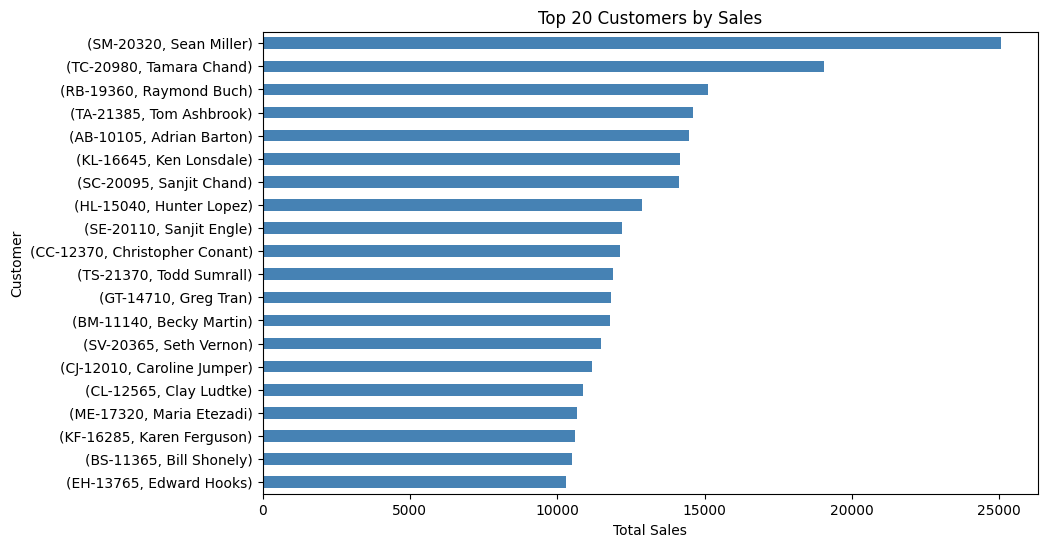

In [43]:
top_customers = df.groupby(["Customer ID","Customer Name"])["Sales"].sum() \
                  .sort_values(ascending=False).head(20)

print("Top 20 Customers by Sales:")
print(top_customers)

# Quick bar chart
plt.figure(figsize=(10,6))
top_customers.plot(kind="barh", color="steelblue")
plt.title("Top 20 Customers by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Customer")
plt.gca().invert_yaxis()  # highest at top
plt.show()

Plotting the Cumulative curve in Sales by Customers. Can we apply Pareto principle to customers and Sales ?

Total customers: 793
Customers needed for 80% of sales: 395
That’s about 49.81% of customers


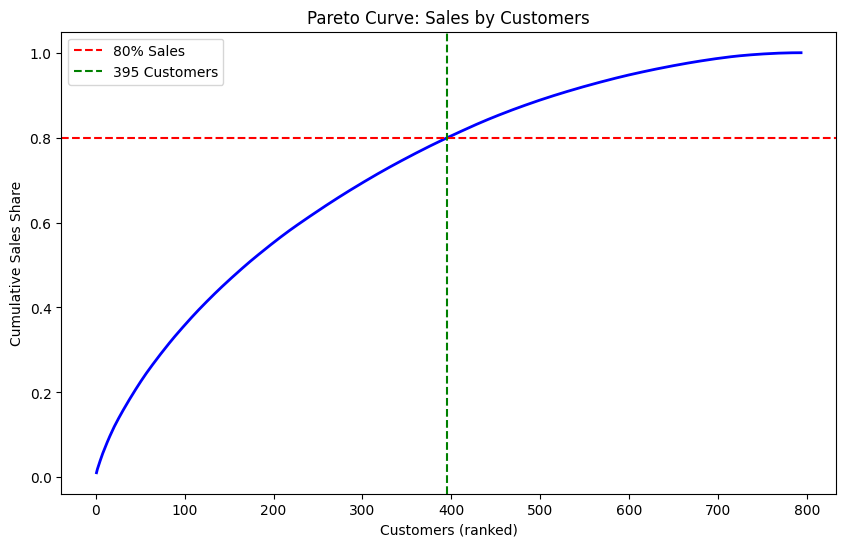

In [44]:
cust_sales = df.groupby("Customer Name")["Sales"].sum().sort_values(ascending=False)

# Calculate cumulative share of sales
cum_sales = cust_sales.cumsum() / cust_sales.sum()

# Find cutoff: number of customers needed to reach 80% of sales
total_customers = len(cust_sales)
top_customers = (cum_sales <= 0.80).sum()
top_percent = 100 * top_customers / total_customers

print(f"Total customers: {total_customers}")
print(f"Customers needed for 80% of sales: {top_customers}")
print(f"That’s about {top_percent:.2f}% of customers")

# Plot cumulative curve
plt.figure(figsize=(10,6))
plt.plot(range(1, total_customers+1), cum_sales.values, color="blue", lw=2)
plt.axhline(0.80, color="red", linestyle="--", label="80% Sales")
plt.axvline(top_customers, color="green", linestyle="--", label=f"{top_customers} Customers")
plt.title("Pareto Curve: Sales by Customers")
plt.xlabel("Customers (ranked)")
plt.ylabel("Cumulative Sales Share")
plt.legend()
plt.show()

**Based on the analysis, make decisions on which states and cities to prioritize for marketing strategies.**

California → Focus on margin improvement, not just sales growth.

New York → Invest in loyalty and retention; customers here are highly profitable.

High-margin smaller states → Targeted growth campaigns to unlock hidden profitability.

Top cities overlap (NYC, Seattle, San Francisco) → Premium positioning and customer experience.

High-sales but low-profit cities (Los Angeles, Chicago) → Pricing and product mix optimization.

Top 20% customers → VIP treatment; they are the backbone of profit.